## Climate Change in Kunduz, Afghanistan

For this project, I wanted to perform a climate change analysis on Northeastern Afghanistan using data from National Centers for Environmental Information (NCEI). The first step that I took was to look for daily summaries stations in Afghanistan. There are less than a handful of stations in the country, and all of them have very low data coverage -- for instance the data coverage of the station in the capital, Kabul, is 58%.

To circumvent this issue, I looked at the stations in the neighboring Central Asian countries. Since my focus is on Northeastern Afghanistan, I checked the station in Dushanbe, Tajikistan, given that Tajikistan not only borders Northeastern Afghanistan but they also share a similar geography, as the former and the latter sit on adjoining mountain ranges-- Pamir and Hindukush. Fortunately, the data coverage of the Dushanbe station is very high (97%), which meant that I could perform my analysis on the Daily Summaries dataset from the Dushanbe station and extrapolate the conclusions toward Northeastern Afghanistan.

<img 
    src = "/workspaces/01-climate-fall-template/img/loc_taj_afg.jpg" 
    alt = "Tajikistan and Afghanistan Location"
    width = 50%
    style="display: block; margin: auto;">
        <p  style="
            text-align: center;
            font-size: 14px;
            color: gray">
                <em>This map was created by Saad Hakim using ESRI's ArcGIS Online.</em>
        </p>
        <p style="
            text-align: center;
            font-size: 14px;
            color: gray;">
                Full Attributes: Esri | © OpenStreetMap contributors | TomTom |
                Garmin | FAO | NOAA | USGS | Afghanistan Land Authority (ARAZI)
                Cartography department ENG. اداره اراضی افغانستان ریاست کارتوگرافی |
                Esri, Michael Bauer Research GmbH 2024, State Statistical Committee
                of Tajikistan
        </p>
    </img>

To futher ensure the validity of my extrapolation, I decided to narrow down my geographic scope to Kunduz Province in the western edge of Northeastern Afghanistan, which shares similar elevation and temperature with Southwestern Tajikistan where Dushanbe is located (as can be seen in the maps below).

<div style="display: flex; justify-content: center; gap: 20px;">
    <div style="width: 45%; text-align: center;">
        <img 
            src="/workspaces/01-climate-fall-template/img/elevation_taj_afg_unit.jpg" 
        >
            <p style="
                font-size: 14px;
                color: gray;">
                <em>This map was created by Saad Hakim using ESRI's ArcGIS Online.</em>
            </p>
            <p style="
                font-size: 14px;
                color: gray;">
                Full Attributes: Esri | © OpenStreetMap contributors | TomTom |
                 Garmin | FAO | NOAA | USGS | Source: USGS | Afghanistan Land 
                 Authority(ARAZI) Cartography department ENG. اداره اراضی
                  افغانستان ریاست کارتوگرافی | Esri, Michael Bauer Research 
                  GmbH 2024, State Statistical Committee of Tajikistan
            </p>
    </div>
    <div style="
    width: 1px;
    background-color: #000;
    margin: 0 20px;
    "></div>
    <div style="width: 45%; text-align: center;">
        <img 
            src="/workspaces/01-climate-fall-template/img/climate_taj_afg.jpg" 
        >
            <p style="
                font-size: 14px;
                color: gray;">
                <em>This map was created by Saad Hakim using ESRI's ArcGIS Online.</em>
            </p>
            <p style="
                font-size: 14px;
                color: gray;">
                Full Attributes: Esri | © OpenStreetMap contributors | TomTom | 
                Garmin | FAO | NOAA | USGS | CHELSA, Conservation International, 
                Esri | Afghanistan Land Authority(ARAZI) Cartography department 
                ENG. اداره اراضی افغانستان ریاست کارتوگرافی | Esri, Michael 
                Bauer Research GmbH 2024, State Statistical Committee of Tajikistan
            </p>
    </div>

</div>

In [1]:
### import libraries

### manage local data
import earthpy 
### save interactive plots
import holoviews as hv 
### make interactive plots
import hvplot.pandas 
### work with tabular data
import pandas as pd ### work with tabular data
### advanced options on matplotlib/seaborn/pandas plots
import matplotlib.pyplot as plt
### common statistical plots for tabular data
import seaborn as sns
### fit an OLS linear regression
from sklearn.linear_model import LinearRegression

### Loading and Saving the Data
The code in the first cell below set the URL for the daily summaries data for the Dushanbe station from 1930-2022. The data coverage of the station starts from 1926, so I chose 1930 as the start date, taking into consideration the possibility of glitches in the inital years of the station's work. I chose 2022 as the end date, considerng the potential delay in relaying updated data.

The code in the second cell below read the daily summaries from the URL into a dataframe.

The third cell saved the dataframe as a csv file. 

Now, that I have the csv file, I have commented out the following three cells, so I don't have to run the whole thing again, given that I can use the saved csv file for my analysis.

In [2]:
# ### make URL for data
# ncei_url = ('https://www.ncei.noaa.gov/access/services/da'
#             'ta/v1?dataset=daily-summaries&dataTypes=TAVG&stations'
#             '=TI000038836&startDate=1930-01-01&endDate=2022-12-31&units=standard')

# ncei_url

In [3]:
# ### get the data using URL
# dushanbe_temp_df = pd.read_csv(
#     ncei_url, 

#     ### set the index column to DATE
#     index_col = 'DATE',

#     ### parse the index column as date-time
#     parse_dates = True,

#     ### set NA values to NaN
#     na_values = ['NaN']
#     )

# dushanbe_temp_df


In [4]:
# ### save the climate data
# dushanbe_temp_df.to_csv('dushanbe_temp_1930-2022.csv')

With the csv file at hand, I can read from it directly.

In [5]:
### get the data from the local CSV file
dushanbe_temp_df = pd.read_csv(
    'dushanbe_temp_1930-2022.csv', 
    
    ### set the index column to DATE
    index_col = 'DATE',

    ### parse the index column as date-time
    parse_dates = True,

    ### set NA values to NaN
    na_values = ['NaN']
    )

dushanbe_temp_df

,STATION,TAVG
DATE,,
1930-01-01,TI000038836,17.0
1930-01-02,TI000038836,22.0
1930-01-03,TI000038836,18.0
1930-01-04,TI000038836,22.0
1930-01-05,TI000038836,28.0
...,...,...
2022-12-27,TI000038836,47.0
2022-12-28,TI000038836,45.0
2022-12-29,TI000038836,40.0


In [6]:
### check that data was imported into a pandas DF
type(dushanbe_temp_df)

pandas.core.frame.DataFrame

### Cleaning and Preparing the Data
In the following two cells, I clean up the data by only retaining the relevant columns and giving an expressive name to the temperature column.

In [7]:
### create a dataframe with only the TAVG column
dushanbe_temp_df = dushanbe_temp_df[['TAVG']]

dushanbe_temp_df

,TAVG
DATE,
1930-01-01,17.0
1930-01-02,22.0
1930-01-03,18.0
1930-01-04,22.0
1930-01-05,28.0
...,...
2022-12-27,47.0
2022-12-28,45.0
2022-12-29,40.0


In [8]:
### make a new DF with expressive column name
dushanbe_temp_units_df = dushanbe_temp_df.rename(columns={
    'TAVG': 'avg_temp_fahr',
})

dushanbe_temp_units_df

,avg_temp_fahr
DATE,
1930-01-01,17.0
1930-01-02,22.0
1930-01-03,18.0
1930-01-04,22.0
1930-01-05,28.0
...,...
2022-12-27,47.0
2022-12-28,45.0
2022-12-29,40.0


In the cell below, following DRY Coding, I write a function, which I may have to use later as well, to convert fahrenheit to celsius. Then, I create another temperature column with celsius temperature (coverted from the fahrenheit column).
* While I use the celsius data for almost all of the rest of the project, I decide to keep the fahrenheit column, just as a reference that I can cross-check in case I am not sure about or find discrepancies in the analyses and visualizations.

In [9]:
### convert units with a function
def fahr_to_cel(temperature):
    """Convert temperature to Celsius"""

    return (temperature - 32) * (5 / 9)

### use fnxn to add a celsius col
dushanbe_temp_units_df['avg_temp_cel'] = (
    dushanbe_temp_units_df['avg_temp_fahr']
    .apply(fahr_to_cel)
    )

dushanbe_temp_units_df

,avg_temp_fahr,avg_temp_cel
DATE,,
1930-01-01,17.0,-8.333333
1930-01-02,22.0,-5.555556
1930-01-03,18.0,-7.777778
1930-01-04,22.0,-5.555556
1930-01-05,28.0,-2.222222
...,...,...
2022-12-27,47.0,8.333333
2022-12-28,45.0,7.222222
2022-12-29,40.0,4.444444


### Visualizing the Data
Here, I initially plot the data to see if any insights and patterns emerge from the data in its basically raw form.
* While, if we squint, we can see a trend upward in temperature through time, the plot is too messy -- so I go ahead and resample the data to resolve some of the clutter and faciliate better analysis and visualization of the data at hand. 

<Axes: title={'center': 'Average Daily Temperature in Dushanbe, Tajikistan'}, xlabel='Date', ylabel='Temperature ($^\\circ$C)'>

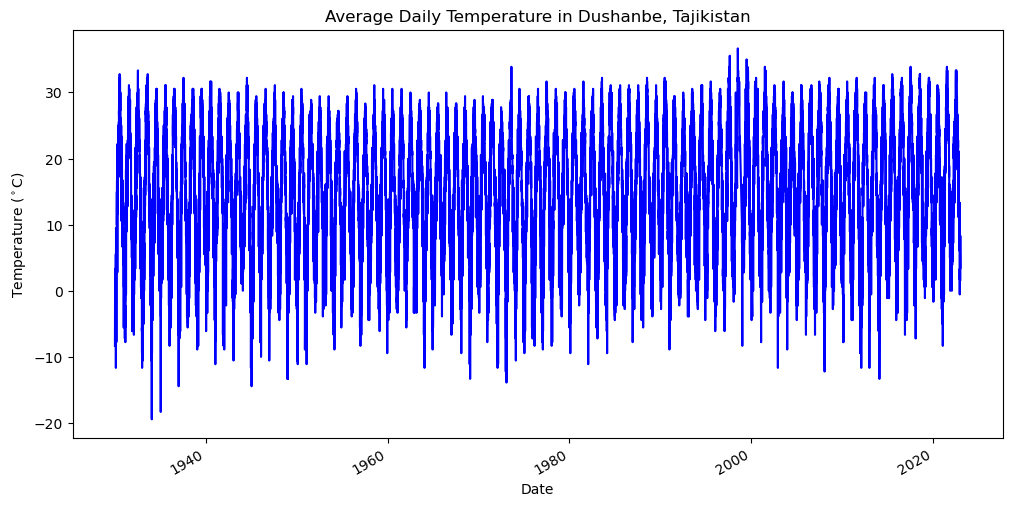

In [10]:
### plot the celsius data using .plot
dushanbe_temp_units_df.plot(
        y = 'avg_temp_cel',
        title = 'Average Daily Temperature in Dushanbe, Tajikistan',
        xlabel = 'Date',
        ylabel = 'Temperature ($^\circ$C)',
        figsize = (12, 6),
        color = 'blue',
        legend = False)

#### Resampling
I decide to resample the data to an annual frequency, because as we can see in the plot above, the temperature fluctuates in a sinusoidal pattern throughout the year, which makes sense since Tajikistan has all four seasons (CountryReports, 2026). So, in order to determine a pattern in long-term climate change, I concluded that resampling the data on a yearly basis, taking average for every year, will resolve the factor of seasonal temperature fluctation and allow us to see the trends of change in climate more clearly.

In [11]:
### resample data to ann. freq. with mean
dush_ann_temp_df = (

    ### resample df
    dushanbe_temp_units_df

    ### sample annually
    .resample('YS')

    ### take mean
    .mean()
)

dush_ann_temp_df

,avg_temp_fahr,avg_temp_cel
DATE,,
1930-01-01,58.123288,14.512938
1931-01-01,57.830137,14.350076
1932-01-01,58.327869,14.626594
1933-01-01,59.013699,15.007610
1934-01-01,56.813699,13.785388
...,...,...
2018-01-01,61.608219,16.449011
2019-01-01,61.358904,16.310502
2020-01-01,59.543716,15.302064


<Axes: title={'center': 'Annual Mean Temperature in Dushanbe, Tajikistan'}, xlabel='Year', ylabel='Temperature ($^\\circ$C)'>

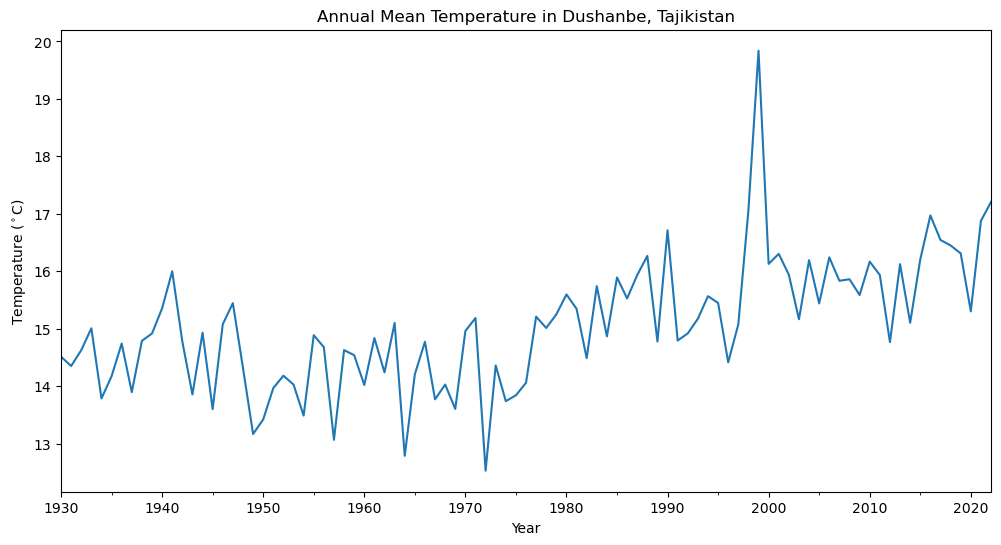

In [12]:
### plot the annual celsius temperature data
dush_ann_temp_df.plot(
    y = 'avg_temp_cel',
    title = 'Annual Mean Temperature in Dushanbe, Tajikistan',
    xlabel = 'Year',
    ylabel = 'Temperature ($^\circ$C)',
    legend = False,
    figsize = (12, 6)
)

_The plot above, drawn after our resampling, is easier to analyze. As we can, there is a trend of rise in temperature, especially between around 1970s and the present._
* There seems to be an outlying spike in temperature in 1999. I believe that is due to data error for two main reasons: 1) from what I browsed over the web, I did not find any report of a temperature spike or a potential cause for such a singular temperature increase in 1999 in Tajikistan or the broader region and 2) in the graphs included in the articles that I have cited below, there doesn't seem to be a similar spike in Tajikistan's (or Central Asia's) temperature in 1999.

#### Interactive Visualization
I made an interactive plot to allow us to engage with the graph upclose and more directly. 

In [13]:
hvplot.extension('bokeh')

In [14]:
### plot the annual celsius data interactively
dush_ann_temp_plot = dush_ann_temp_df.hvplot(
    y = 'avg_temp_cel',
    title = 'Annual Mean Temperature in Dushanbe, Tajikistan',
    xlabel = 'Year',
    ylabel = 'Temperature (deg C)',
    legend = False,
)

dush_ann_temp_plot

:Curve   [DATE]   (avg_temp_cel)

It appears that the maximum annual mean temperature between 1930-2022 is _19.839 celsius_ in 1999. If we disregard this due to potential data error, then the maximum annual mean temperature would be _17.207 celsius_ in 2022, which is in itself telling about the rise in temperature due to climate change. 

On the other hand, the minimum annual mean temperature for our period is _12.527 celsius_ in 1972. All the subsequent low annual mean temperatures are at least 1 degree of celsius higher than this.

_Before continuing with my analysis, I double-check whether there are any null values in my dataset, which might cause problems for my analysis. 93 non-null values per column for 93 entries -- Perfect!_

In [15]:
### x2-check if there are null values in DF
dush_ann_temp_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 93 entries, 1930-01-01 to 2022-01-01
Freq: YS-JAN
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   avg_temp_fahr  93 non-null     float64
 1   avg_temp_cel   93 non-null     float64
dtypes: float64(2)
memory usage: 2.2 KB


### Linear Ordinary Least Squares (OLS) Regression

I decided to use Linear Ordinary Least Squares (OLS) Regression after considering the following assumptions:

* **Random Error:** With the exception of the above-mentioned data anomaly in 1999, our data seems to be consistent.

* **Normally Distributed Data:**  Since we are looking at annual mean temperature, the data is more or less normally distributed, adding support to our choice.

* **Linearity:** Since Tajikstan (and Northeastern Afghanistan by extension) is in mid-latitudes and not subject to extreme temperature swings, we can assume linearity in its temperature trends.

* **Stationarity:** The data, with only the above-mentioned exception, does not see extreme year-to-year variability, making it mostly align with the stationarity assumption.


In [16]:
### fit an OLS Linear Regression to the data

### define independent variable
### reshape 'year' to be a 2D array for scikit-learn
ind_variable = dush_ann_temp_df.index.year.values.reshape(-1, 1)


### define dependent variable
dep_variable = dush_ann_temp_df['avg_temp_cel']


### make linear regression model
model = LinearRegression()


### fit the model on the data
model.fit(ind_variable, dep_variable)


### calculate and print metrics
print(f'Slope: {model.coef_[0]} degrees per year')
print(f'Slope: {model.coef_[0] * 10} degrees per decade')

Slope: 0.025580842112153904 degrees per year
Slope: 0.255808421121539 degrees per decade


Here, we printed out the year-by-year and decade-by-decade slopes of the regression model -- there is a positive rate of increase in temperature. We will use this later in our analysis.

#### Plot Trendline
Plotting the trendline helps us visualize the increasing trend of temperature over the almost-hundred-year period under consideration.

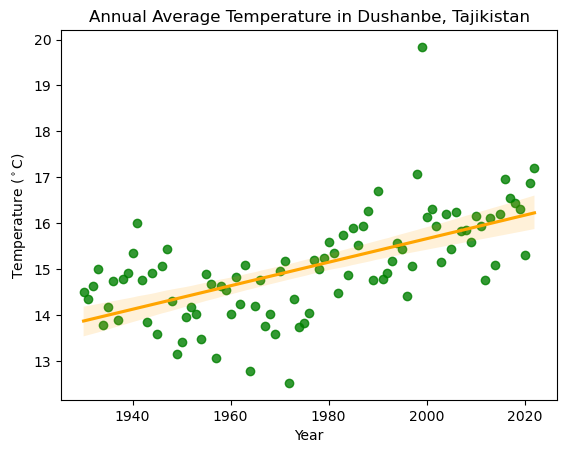

In [17]:
### plot data
ax = sns.regplot(
    x = dush_ann_temp_df.index.year, 
    y = dush_ann_temp_df.avg_temp_cel,

    ### change data points color
    scatter_kws={'color': 'green'},

    ### change trendline color
    line_kws={'color': 'orange'}
)

### make labels
ax.set(
    title = 'Annual Average Temperature in Dushanbe, Tajikistan',
    xlabel = 'Year',
    ylabel = 'Temperature ($^\circ$C)',
)

### save your plot
plt.savefig('/workspaces/01-climate-fall-template/ann_avg_temp_tl_Dushanbe.jpeg')

### plot it
plt.show()

Interpretation for Takistan

Interpretation for Kunduz